In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/PlantVillage.zip /content

In [ ]:
!unzip /content/PlantVillage.zip

Streaming output truncated to the last 5000 lines.
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1382).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1383).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1384).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1385).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1386).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1387).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1388).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1389).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (139).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1390).JPG  
  inflating: PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1391).JPG  
  inflating: PlantVillage/

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
data_dir = "/content/PlantVillage"

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(data_dir, transform=train_transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Classes:", dataset.classes)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___T

In [ ]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

num_classes = len(dataset.classes)
model.classifier[6] = nn.Linear(4096, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0003)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.7MB/s]


In [ ]:
epochs = 10
best_accuracy = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_acc_list = []
val_acc_list = []

for epoch in range(epochs):
    print(f"\nEpoch [{epoch+1}/{epochs}]")

    model.train()
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_acc_list.append(train_accuracy)
    print("Train Accuracy:", train_accuracy)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_acc_list.append(val_accuracy)
    print("Validation Accuracy:", val_accuracy)

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_model.pth")
        print("Best model saved!")

print("\nBest Validation Accuracy:", best_accuracy)


Epoch [1/10]
Train Accuracy: 75.85459312292024
Validation Accuracy: 86.92941176470588
Best model saved!

Epoch [2/10]
Train Accuracy: 85.18705253604921
Validation Accuracy: 88.67058823529412
Best model saved!

Epoch [3/10]
Train Accuracy: 86.63154179691439
Validation Accuracy: 90.12941176470588
Best model saved!

Epoch [4/10]
Train Accuracy: 87.79872945447212
Validation Accuracy: 90.17647058823529
Best model saved!

Epoch [5/10]
Train Accuracy: 88.67096904305738
Validation Accuracy: 91.11764705882354
Best model saved!

Epoch [6/10]
Train Accuracy: 88.94827064636483
Validation Accuracy: 90.49411764705883

Epoch [7/10]
Train Accuracy: 89.43985076131895
Validation Accuracy: 91.31764705882352
Best model saved!

Epoch [8/10]
Train Accuracy: 89.92386810527377
Validation Accuracy: 92.49411764705883
Best model saved!

Epoch [9/10]
Train Accuracy: 89.8381567006151
Validation Accuracy: 91.5764705882353

Epoch [10/10]
Train Accuracy: 90.21629525057982
Validation Accuracy: 92.5764705882353
Best m

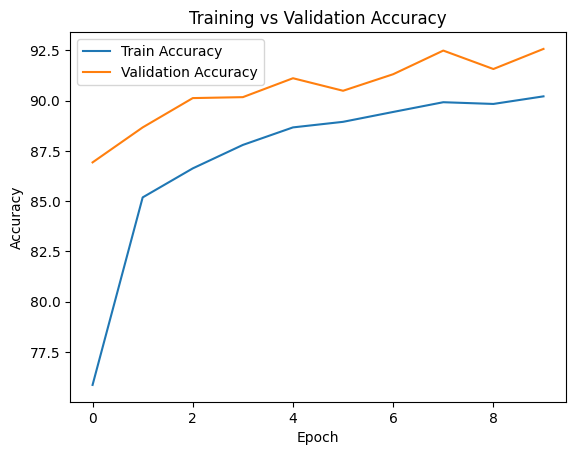

In [ ]:
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()

In [ ]:
torch.save(best_model_wts, "best_model.pth")

In [ ]:
import json

with open("classes.json", "w") as f:
    json.dump(dataset.classes, f)
print("classes.json saved successfully")


classes.json saved successfully


In [ ]:
from google.colab import files

files.download("best_model.pth")
files.download("classes.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>